In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Waste_waters";',
    engine
)
df

,Id,Year,Total,From_households,From_the_economy,From_other_users,From_own_consumption
0,9,2017,111346.841,81645.637,22703.665,1520.839,5476.700
1,10,2018,108433.758,78912.761,21731.014,2748.283,5041.700
2,11,2019,107605.566,80847.508,19724.502,2580.656,4452.900
3,12,2020,140056.606,96746.946,31402.480,2954.180,8953.000
4,13,2021,108930.597,83812.631,17622.909,2640.681,4854.376
5,14,2022,105292.618,80544.991,20110.915,3084.312,1552.400
6,15,2023,104865.970,80167.301,20428.765,2701.004,1568.900
7,16,2024,117428.525,91467.441,21548.670,2798.626,1613.788


In [3]:
df = df.drop(columns=["Id"])
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2025, 2026, 2027, 2028, 2029]})

In [4]:
import os

os.makedirs("../models/Waste_waters", exist_ok=True)

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
import joblib

forecasts = {}
best_params = {}

for col in columns_to_model:
    X = df[["Year"]].values
    y = df[col].values

    knn = KNeighborsRegressor()
    param_grid = {
        "n_neighbors": [2, 3, 4, 5],
        "weights": ["uniform", "distance"]
    }

    grid = GridSearchCV(knn, param_grid, cv=min(len(X), 5), scoring='neg_mean_squared_error')
    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_params[col] = grid.best_params_

    pred = best_model.predict(future_years[["Year"]].values)
    forecasts[col] = pred

    joblib.dump(best_model, f"../models/Waste_waters/{col}_knn_model.pkl")

df_forecast = pd.DataFrame(forecasts, index=future_years["Year"])
print(df_forecast)

print("\nBest parameters per column:")
for col, params in best_params.items():
    print(f"{col}: {params}")


            Total  From_households  From_the_economy  From_other_users  \
Year                                                                     
2025  115314.8632        86547.862        22222.7478       2823.944727   
2026  115314.8632        86547.862        22222.7478       2834.516000   
2027  115314.8632        86547.862        22222.7478       2840.411149   
2028  115314.8632        86547.862        22222.7478       2844.177243   
2029  115314.8632        86547.862        22222.7478       2846.792449   

      From_own_consumption  
Year                        
2025           1598.825333  
2026           1595.832800  
2027           1594.550286  
2028           1593.837778  
2029           1593.384364  

Best parameters per column:
Total: {'n_neighbors': 5, 'weights': 'uniform'}
From_households: {'n_neighbors': 5, 'weights': 'uniform'}
From_the_economy: {'n_neighbors': 5, 'weights': 'uniform'}
From_other_users: {'n_neighbors': 3, 'weights': 'distance'}
From_own_consumption: {'

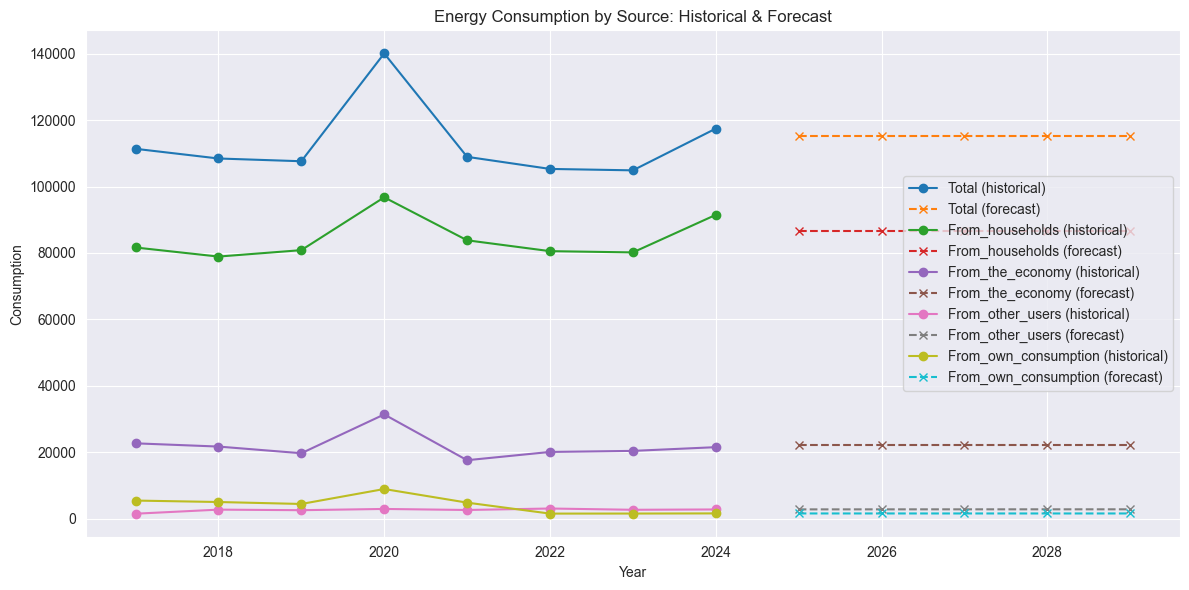

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for col in columns_to_model:
    plt.plot(df["Year"], df[col], marker='o', label=f"{col} (historical)")
    plt.plot(future_years["Year"], df_forecast[col], marker='x', linestyle='--', label=f"{col} (forecast)")

plt.title("Energy Consumption by Source: Historical & Forecast")
plt.xlabel("Year")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
